## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install --force-reinstall numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 sklearn-pandas==2.2.0 -q

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [713]:
# Pandas are imported here To read .csv file
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)


In [714]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the dataset

In [715]:
loan_data = pd.read_csv("/content/drive/MyDrive/Notebooks/Loan_Modelling.csv")
loan_details = loan_data.copy()

## Data Overview

* Observations
* Sanity checks

In [716]:
loan_details.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [717]:
loan_details.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [718]:
loan_details.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [719]:
loan_details.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [720]:
loan_details.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

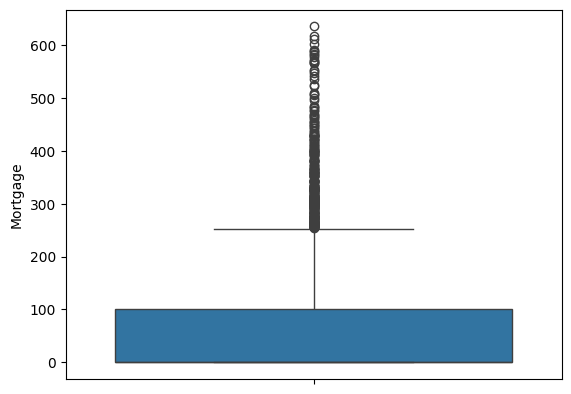

In [721]:
sns.boxplot(data=loan_details, y='Mortgage');

**Mortgage:**

*   From the boxplot, we can see that most people's mortgage are relatively
low, mostly under 100k.
*   Median looks small compared to the overall scale
*   The upper whisker extends to around 250K which means values upto 250 K are still considered within normal spread.
*   There are many outliers, i.e, people with very large mortgages from 250 K to beyond 600k.






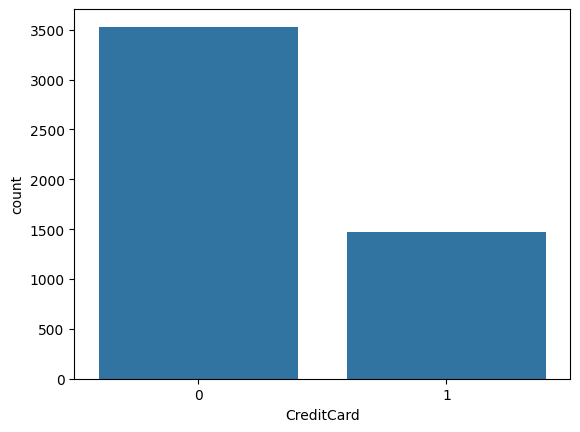

In [722]:
sns.countplot(data=loan_details, x='CreditCard');

 Observations: 1500 use 1 credit card issued by other Bank and 3500 customers donot have any other credit card

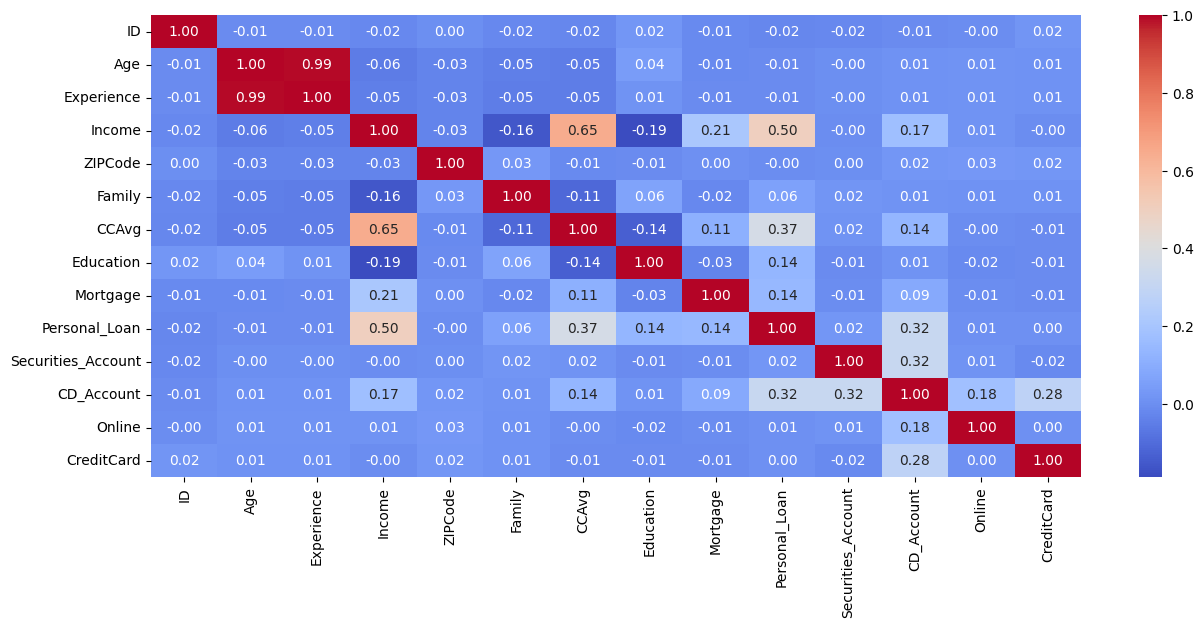

In [723]:
# To understand correlation lets use the heatmap
corr = loan_details.corr(numeric_only=True)
plt.figure(figsize= (15,6))
sns.heatmap(corr, annot=True, cmap = "coolwarm", fmt = ".2f")
plt.show()


**Observations**
1. Income and Average spending on credit cards is positively correlated
2. Customers with high Income accepted the Personal_loan offered in the last campaign
3. CCavg and Personal_loan is positively correlated
4. Age and Personal Loan have very slight negitive correlation
5. Education and Personal Loan have positive correlation
6. Age and Experience have very high positive correlation

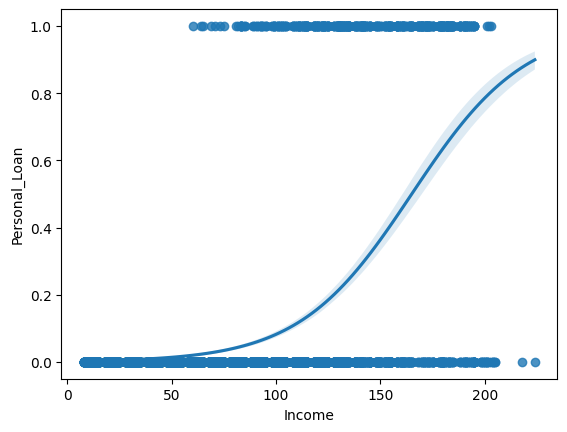

In [724]:
sns.regplot(x="Income", y="Personal_Loan", data = loan_details, logistic = True);

We can Observe that probability of accepting the loan higher in high income groups above 50K and has strong correlation with income mostly till 200K

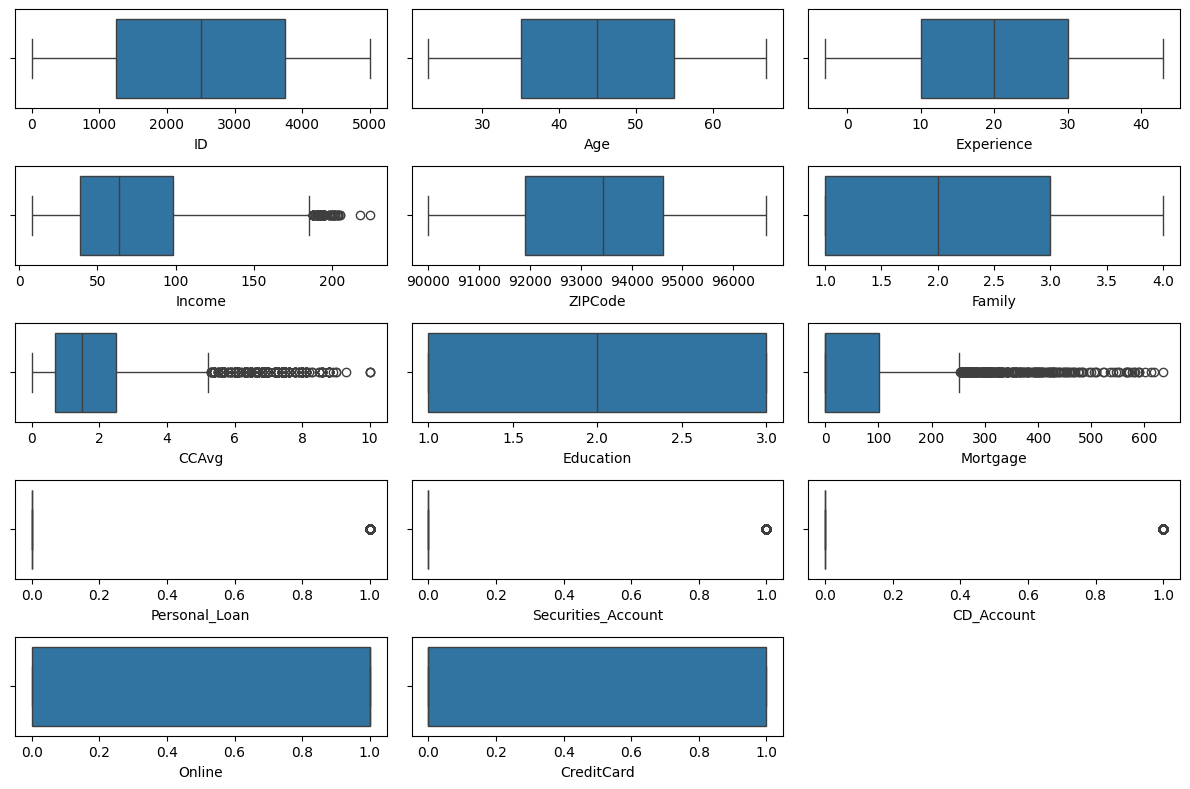

In [725]:
plt.figure(figsize=(12,8))
for index, feature in enumerate(loan_details.columns):
  plt.subplot(5, 3, index+1)
  sns.boxplot(data=loan_details, x=feature)
plt.tight_layout();

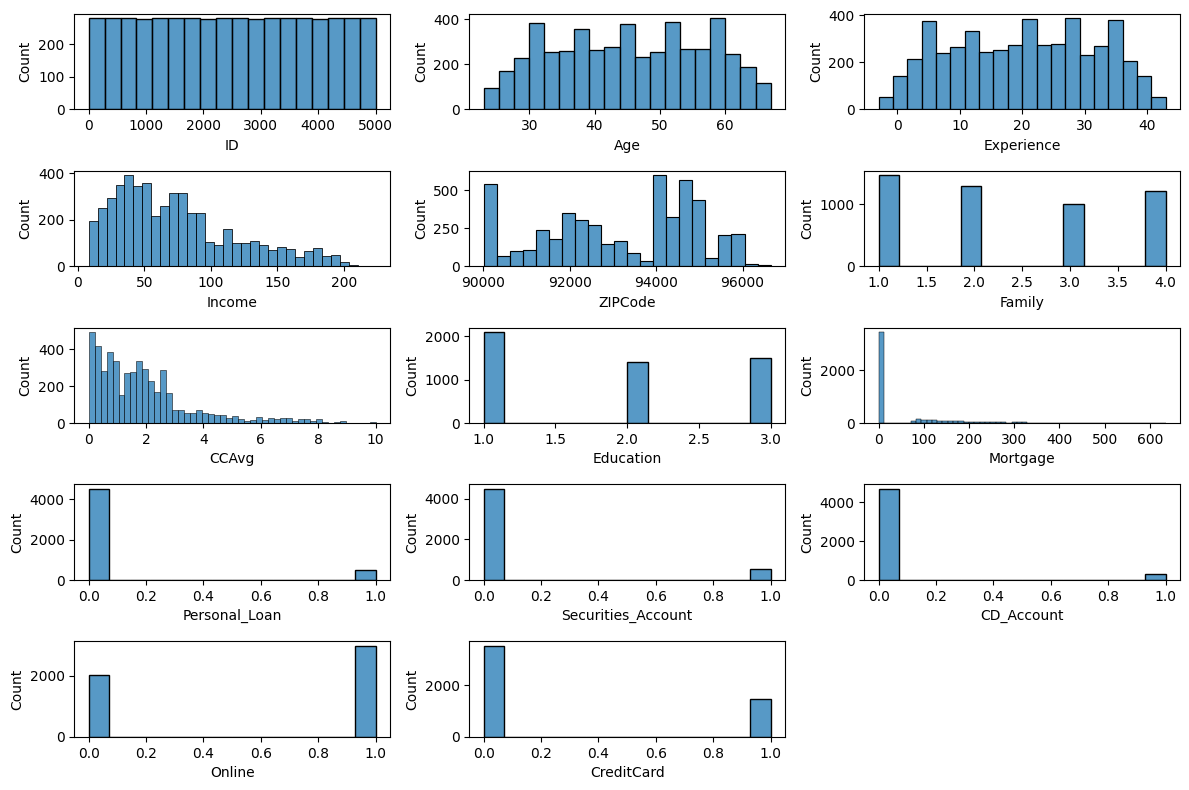

In [726]:
plt.figure(figsize=(12,8))
for index, feature in enumerate(loan_details.columns):
  plt.subplot(5, 3, index+1)
  sns.histplot(data=loan_details, x=feature)

plt.tight_layout();

Income and CC Avg are right skewed

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [727]:
loan_details.duplicated().sum()

np.int64(0)

In [728]:
loan_details.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


In [729]:
# Age and Experience have very high positive correlation, so dropping Experience to prevent repeated rules
# Dropping ID as it is unique and doesnot provide any information related to analysis
loan_details = loan_details.drop(['ID', 'Experience'], axis = 1)

In [730]:
loan_details['ZIPCode'].nunique()

467

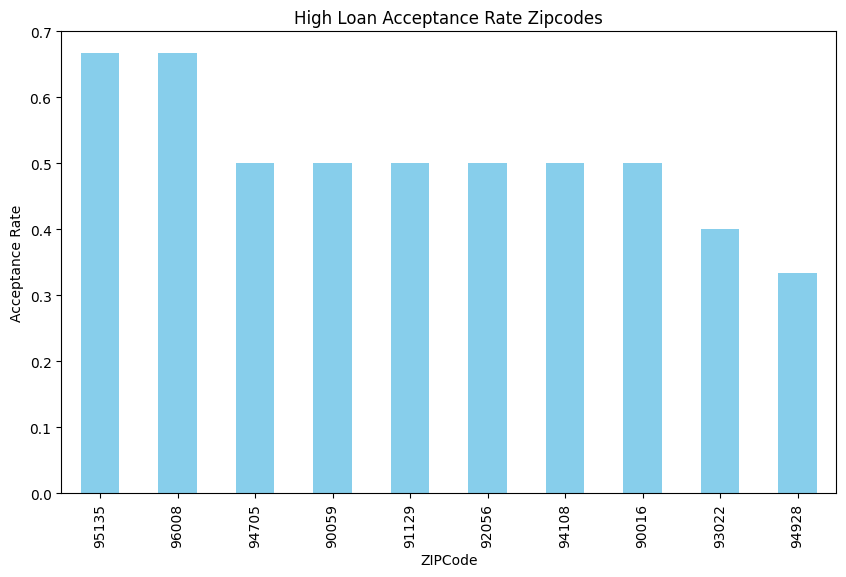

In [731]:
zip_based_loan_summary = loan_details.groupby("ZIPCode")["Personal_Loan"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
zip_based_loan_summary.head(10).plot(kind="bar", color="skyblue")
plt.title("High Loan Acceptance Rate Zipcodes")
plt.ylabel("Acceptance Rate")
plt.show()

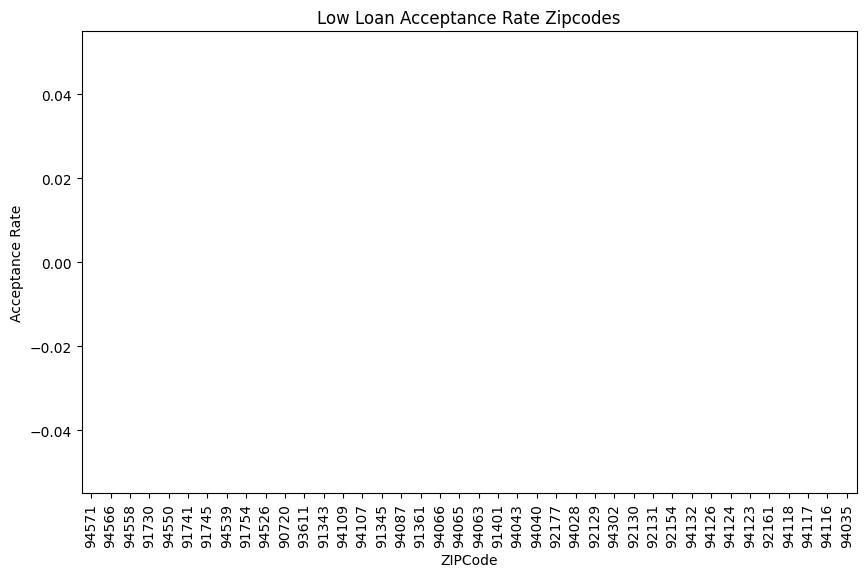

In [732]:
zip_based_loan_summary = loan_details.groupby("ZIPCode")["Personal_Loan"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
zip_based_loan_summary.tail(40).plot(kind="bar", color="skyblue")
plt.title("Low Loan Acceptance Rate Zipcodes")
plt.ylabel("Acceptance Rate")
plt.show()

from the above plot we can see that there are many Zipcodes without the loan acceptance.

In [733]:
loan_details['ZIPCode'] = loan_details['ZIPCode'].astype(str).str.zfill(5).str[:2]
loan_details.head(5)


,Age,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,49,91,4,1.6,1,0,0,1,0,0,0
1,45,34,90,3,1.5,1,0,0,1,0,0,0
2,39,11,94,1,1.0,1,0,0,0,0,0,0
3,35,100,94,1,2.7,2,0,0,0,0,0,0
4,35,45,91,4,1.0,2,0,0,0,0,0,1


In [734]:
loan_details['ZIPCode'].nunique()

7

In [735]:
zip_dummies = pd.get_dummies(loan_details['ZIPCode'], prefix="Zip", dtype=int)
loan_details = pd.concat([loan_details.drop(columns=['ZIPCode']), zip_dummies], axis=1)

In [736]:
loan_details.head(5)

,Age,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Zip_90,Zip_91,Zip_92,Zip_93,Zip_94,Zip_95,Zip_96
0,25,49,4,1.6,1,0,0,1,0,0,0,0,1,0,0,0,0,0
1,45,34,3,1.5,1,0,0,1,0,0,0,1,0,0,0,0,0,0
2,39,11,1,1.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
3,35,100,1,2.7,2,0,0,0,0,0,0,0,0,0,0,1,0,0
4,35,45,4,1.0,2,0,0,0,0,0,1,0,1,0,0,0,0,0


**Zipcode Observations:**

1. In the given data, there are 467 unique zipcodes
2. Zipcodes 95135 and 96008 have high Loan Acceptance
3. There are many zipcodes that have 0 loan acceptance
4. So to simplify the decision trees, I tried to take the advantage of zip prefixes and still capture geographic differences.
5. Using the first 2 digits of zipcode, we have 7 categories of zipcodes.
6. Then the categorial variables are converted using dummies and stored in loan_details as above.

**Data Preparation for Modeling**

In [737]:
X = loan_details.drop('Personal_Loan', axis = 1)
Y = loan_details['Personal_Loan']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20, random_state=42)

In [738]:
loan_details.columns[loan_details.columns.duplicated()]

Index([], dtype='object')

In [739]:
print("Shape of training set:", X_train.shape)
print("Shape of test set:", X_test.shape, '\n')
print("Percentage of classes in training set:")
print(100*Y_train.value_counts(normalize=True), '\n')
print("Percentage of classes in test set:")
print(100*Y_test.value_counts(normalize=True))

Shape of training set: (4000, 17)
Shape of test set: (1000, 17) 

Percentage of classes in training set:
Personal_Loan
0    90.625
1     9.375
Name: proportion, dtype: float64 

Percentage of classes in test set:
Personal_Loan
0    89.5
1    10.5
Name: proportion, dtype: float64


### Model Evaluation Criterion Functions

In [740]:
# To plot the confusion_matrix with percentages
def plot_confusion_matrix(model, predictors, true_targets):
    predicted_targets = model.predict(predictors)
    cm = confusion_matrix(true_targets, predicted_targets)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)    # reshaping to a matrix

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True Values")
    plt.xlabel("Predicted Values")

In [741]:
# computes metrics to check performance of the classification model
def model_performance_classification(model, predictors, true_target_values):

    # predicting using the independent variables
    predicted_target_values = model.predict(predictors)

    accuracy = accuracy_score(true_target_values, predicted_target_values)
    recall = recall_score(true_target_values, predicted_target_values)
    precision = precision_score(true_target_values, predicted_target_values)
    f1 = f1_score(true_target_values, predicted_target_values)

    df_performance = pd.DataFrame(
        {"Accuracy": accuracy, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_performance

In [742]:
def plot_decision_tree(model):
  feature_names = list(X_train.columns)

  plt.figure(figsize=(20, 20))

  # plotting the decision tree
  out = tree.plot_tree(
    model,
    feature_names = feature_names,
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,
    class_names=None,
  )

  # add arrows to the decision tree splits if they are missing
  for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

  # displaying the plot
  plt.show()

In [743]:
def export_tree_text(model):
  feature_names = list(X_train.columns)
  print(
    tree.export_text(
        model,    # specify the model
        feature_names = feature_names,    # specify the feature names
        show_weights=True    # specify whether or not to show the weights associated with the model
    )
  )

### SKLearn Default Model Building

In [744]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=42)

## Default Model Metrics On Train Data

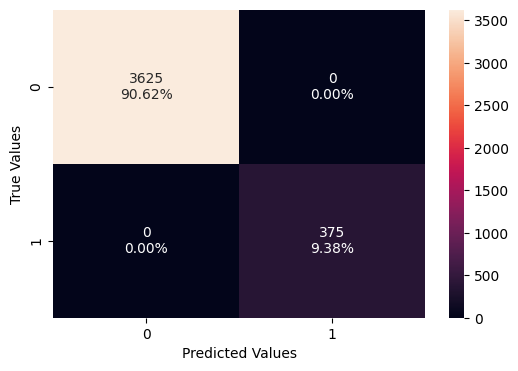

In [745]:
plot_confusion_matrix(dt_model, X_train, Y_train)

In [746]:
dt_train_data_performace = model_performance_classification(
    dt_model, X_train, Y_train
)
dt_train_data_performace

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


Accuracy, Recall, precision, F1 are 1 which indicates all the metrics are perfect to the point. Personal Loan acceptance (Rue Positive)is 9.38% and rejection (True Negitive) is 90.62%,

False Positive and False Negitive are 0, indicating an Overfitting Model

## Default Model Metrics On Test Data

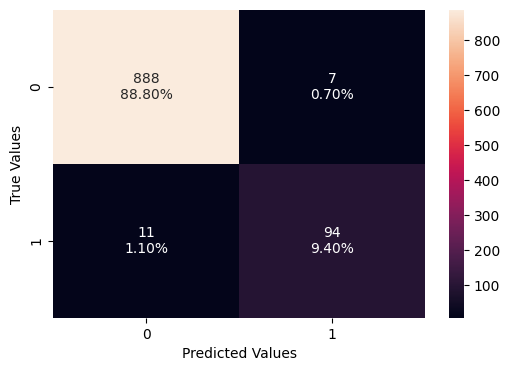

In [747]:
plot_confusion_matrix(dt_model, X_test, Y_test)

In [748]:
dt_test_data_performance = model_performance_classification(
    dt_model, X_test, Y_test
)
dt_test_data_performance

,Accuracy,Recall,Precision,F1
0,0.982,0.895238,0.930693,0.912621


Test Performance is good but as the model is Overfitting it cannot be generalized and very complicated as seen in the below tree.

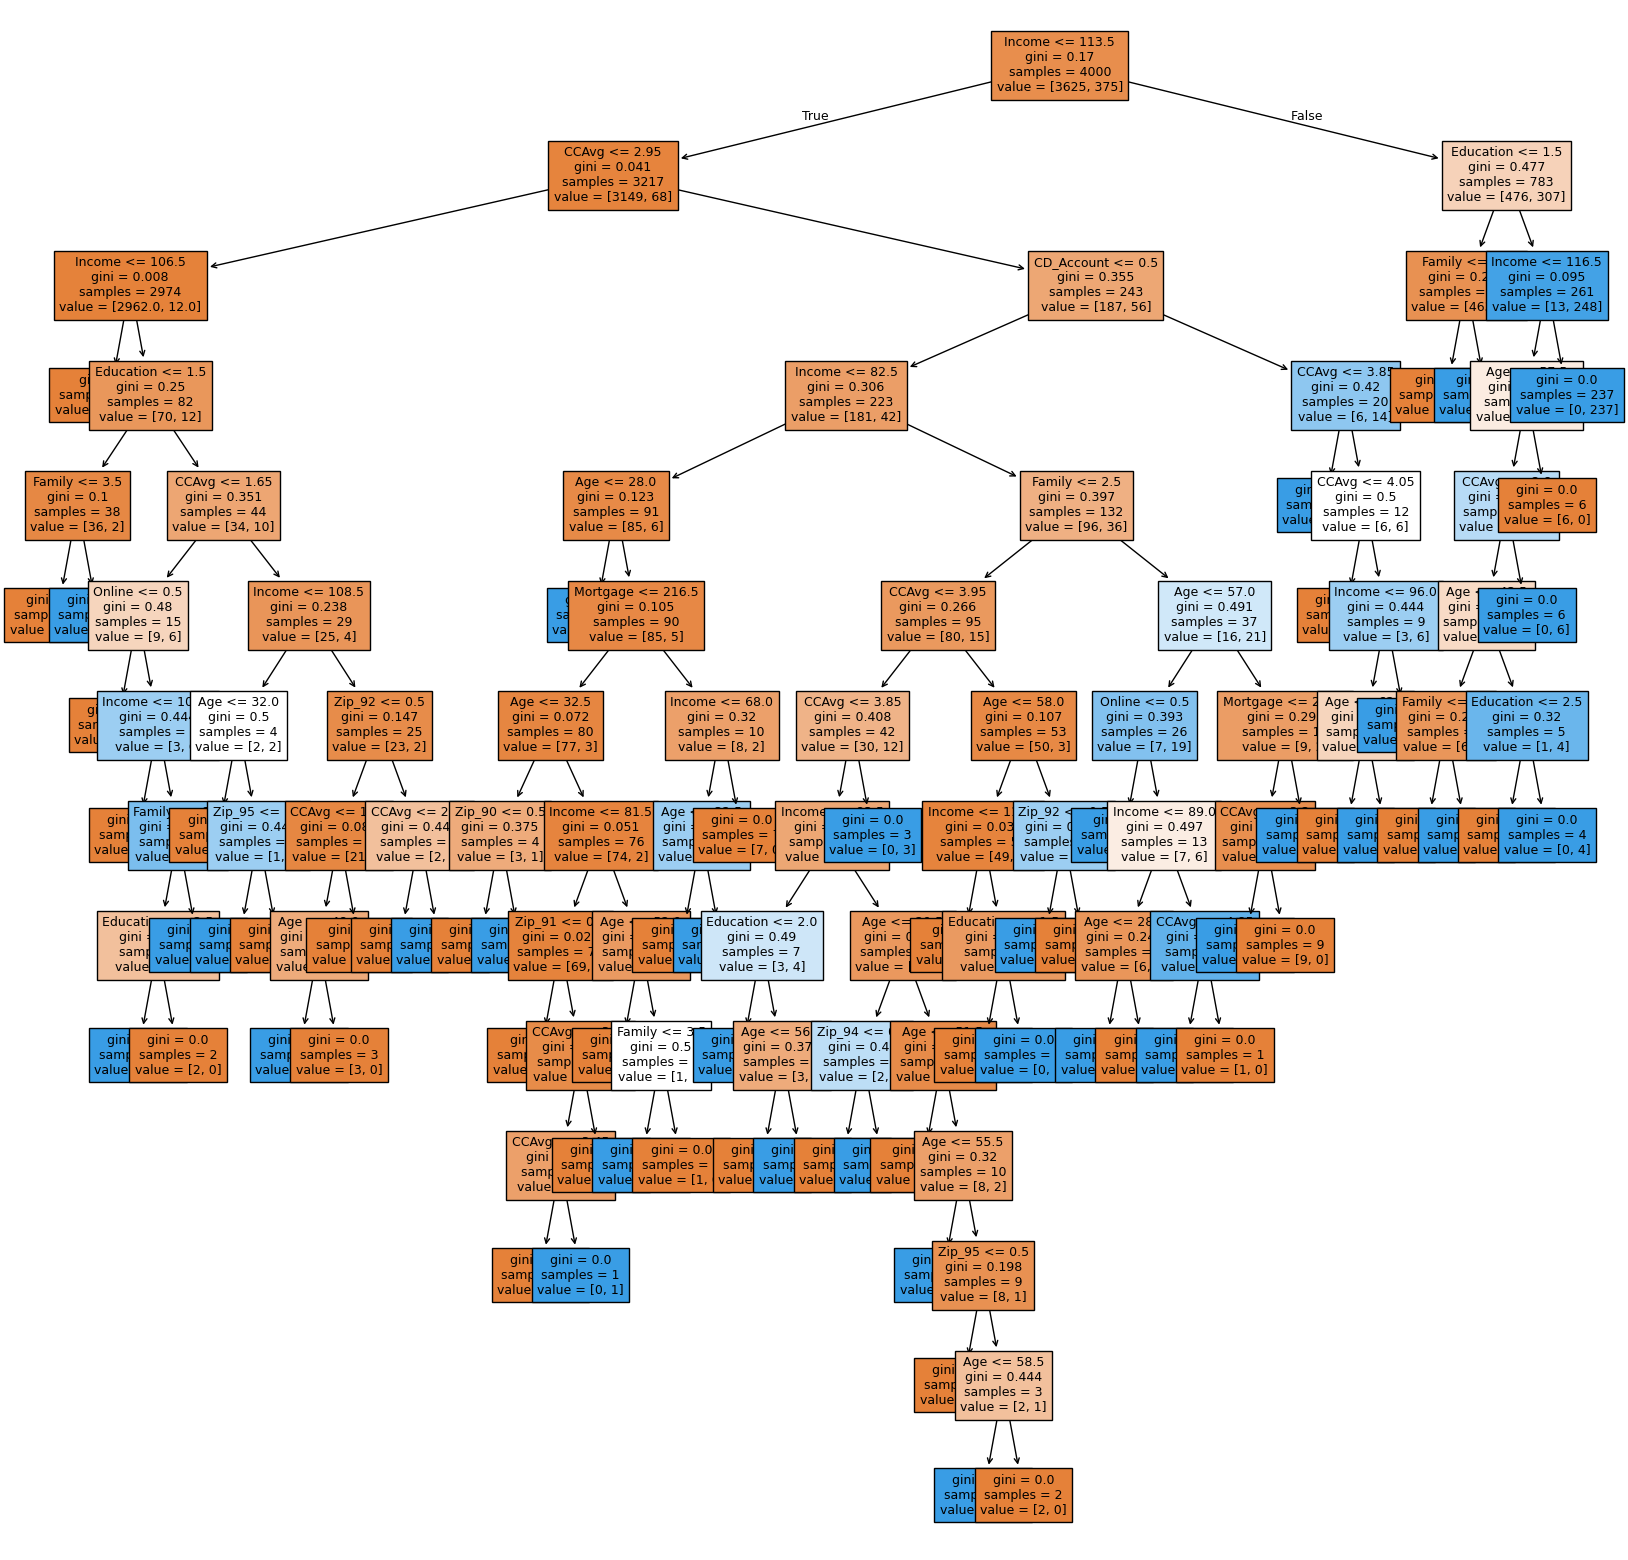

In [749]:
plot_decision_tree(dt_model)

In [750]:
export_tree_text(dt_model)

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2892.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Education <= 1.50
|   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |--- weights: [36.00, 0.00] class: 0
|   |   |   |   |--- Family >  3.50
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Education >  1.50
|   |   |   |   |--- CCAvg <= 1.65
|   |   |   |   |   |--- Online <= 0.50
|   |   |   |   |   |   |--- weights: [6.00, 0.00] class: 0
|   |   |   |   |   |--- Online >  0.50
|   |   |   |   |   |   |--- Income <= 108.50
|   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |--- Income >  108.50
|   |   |   |   |   |   |   |--- Family <= 1.50
|   |   |   |   |   |   |   |   |--- Education <= 2.50
|   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |   |--- Education >  2.50
|   |   |   |   |   |   |   

### Observations of Default Model

This gives a very complicated tree. Tree has taken into consideration all the rules and every observation has its own leaf. In some cases, the leaf samples are greater than 1, which means they are already grouped into same category and there is no impurity, hence gini impurity is 0.

This is Overfitting.

## Model Performance Improvement

### Pre Pruned Decision Tree

PrePruning prevents the tree to grow beyond a certain point by controlling max_depth_values(maximum depth from root to leaves), max_leaf_nodes_values, min_samples_split_values(min datapoints for a node to split)

### Building Pre Pruned Decision Tree

In [751]:
# define the parameters of the tree to iterate over
max_depth_values = np.arange(3, 6, 1)
max_leaf_nodes_values = [50, 75, 150, 200]
min_samples_split_values = [10, 35, 60, 90]

# initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')

# iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initialize the tree with the current set of parameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # fit the model to the training data
            estimator.fit(X_train, Y_train)

            # make predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # calculate F1 scores for training and test sets
            train_f1_score = f1_score(Y_train, y_train_pred)
            test_f1_score = f1_score(Y_test, y_test_pred)

            # calculate the absolute difference between training and test F1 scores
            score_diff = abs(train_f1_score - test_f1_score)

            # update the best estimator and best score if the current one has a smaller score difference
            if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator = estimator

In [752]:
# creating an instance of the best model
pre_pruned_dt = best_estimator

# fitting the best model to the training data
pre_pruned_dt.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=np.int64(5), max_leaf_nodes=50,
                       min_samples_split=10, random_state=42)

### Pre Pruned Decision Tree Metrics

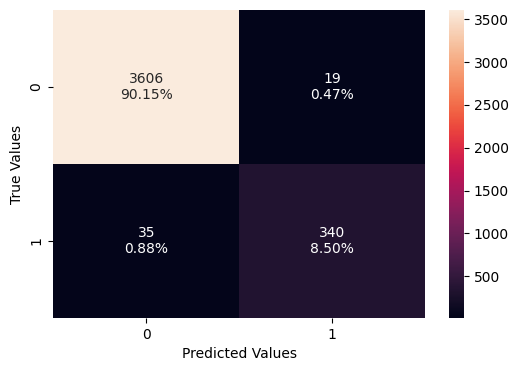

In [753]:
plot_confusion_matrix(pre_pruned_dt, X_train, Y_train)

In [754]:
pre_pruned_dt_train_perf = model_performance_classification(
    pre_pruned_dt, X_train, Y_train
)
pre_pruned_dt_train_perf

,Accuracy,Recall,Precision,F1
0,0.9865,0.906667,0.947075,0.926431


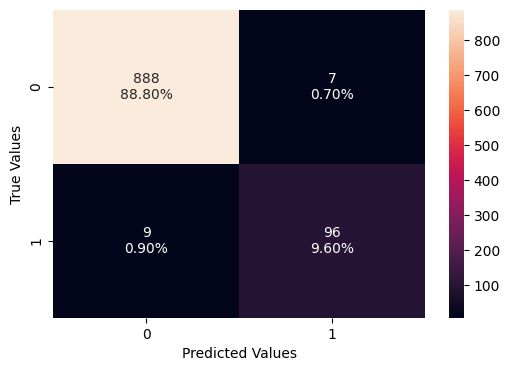

In [755]:
plot_confusion_matrix(pre_pruned_dt, X_test, Y_test)

In [756]:
pre_pruned_dt_test_perf = model_performance_classification(
    pre_pruned_dt, X_test, Y_test
)
pre_pruned_dt_train_perf

,Accuracy,Recall,Precision,F1
0,0.9865,0.906667,0.947075,0.926431


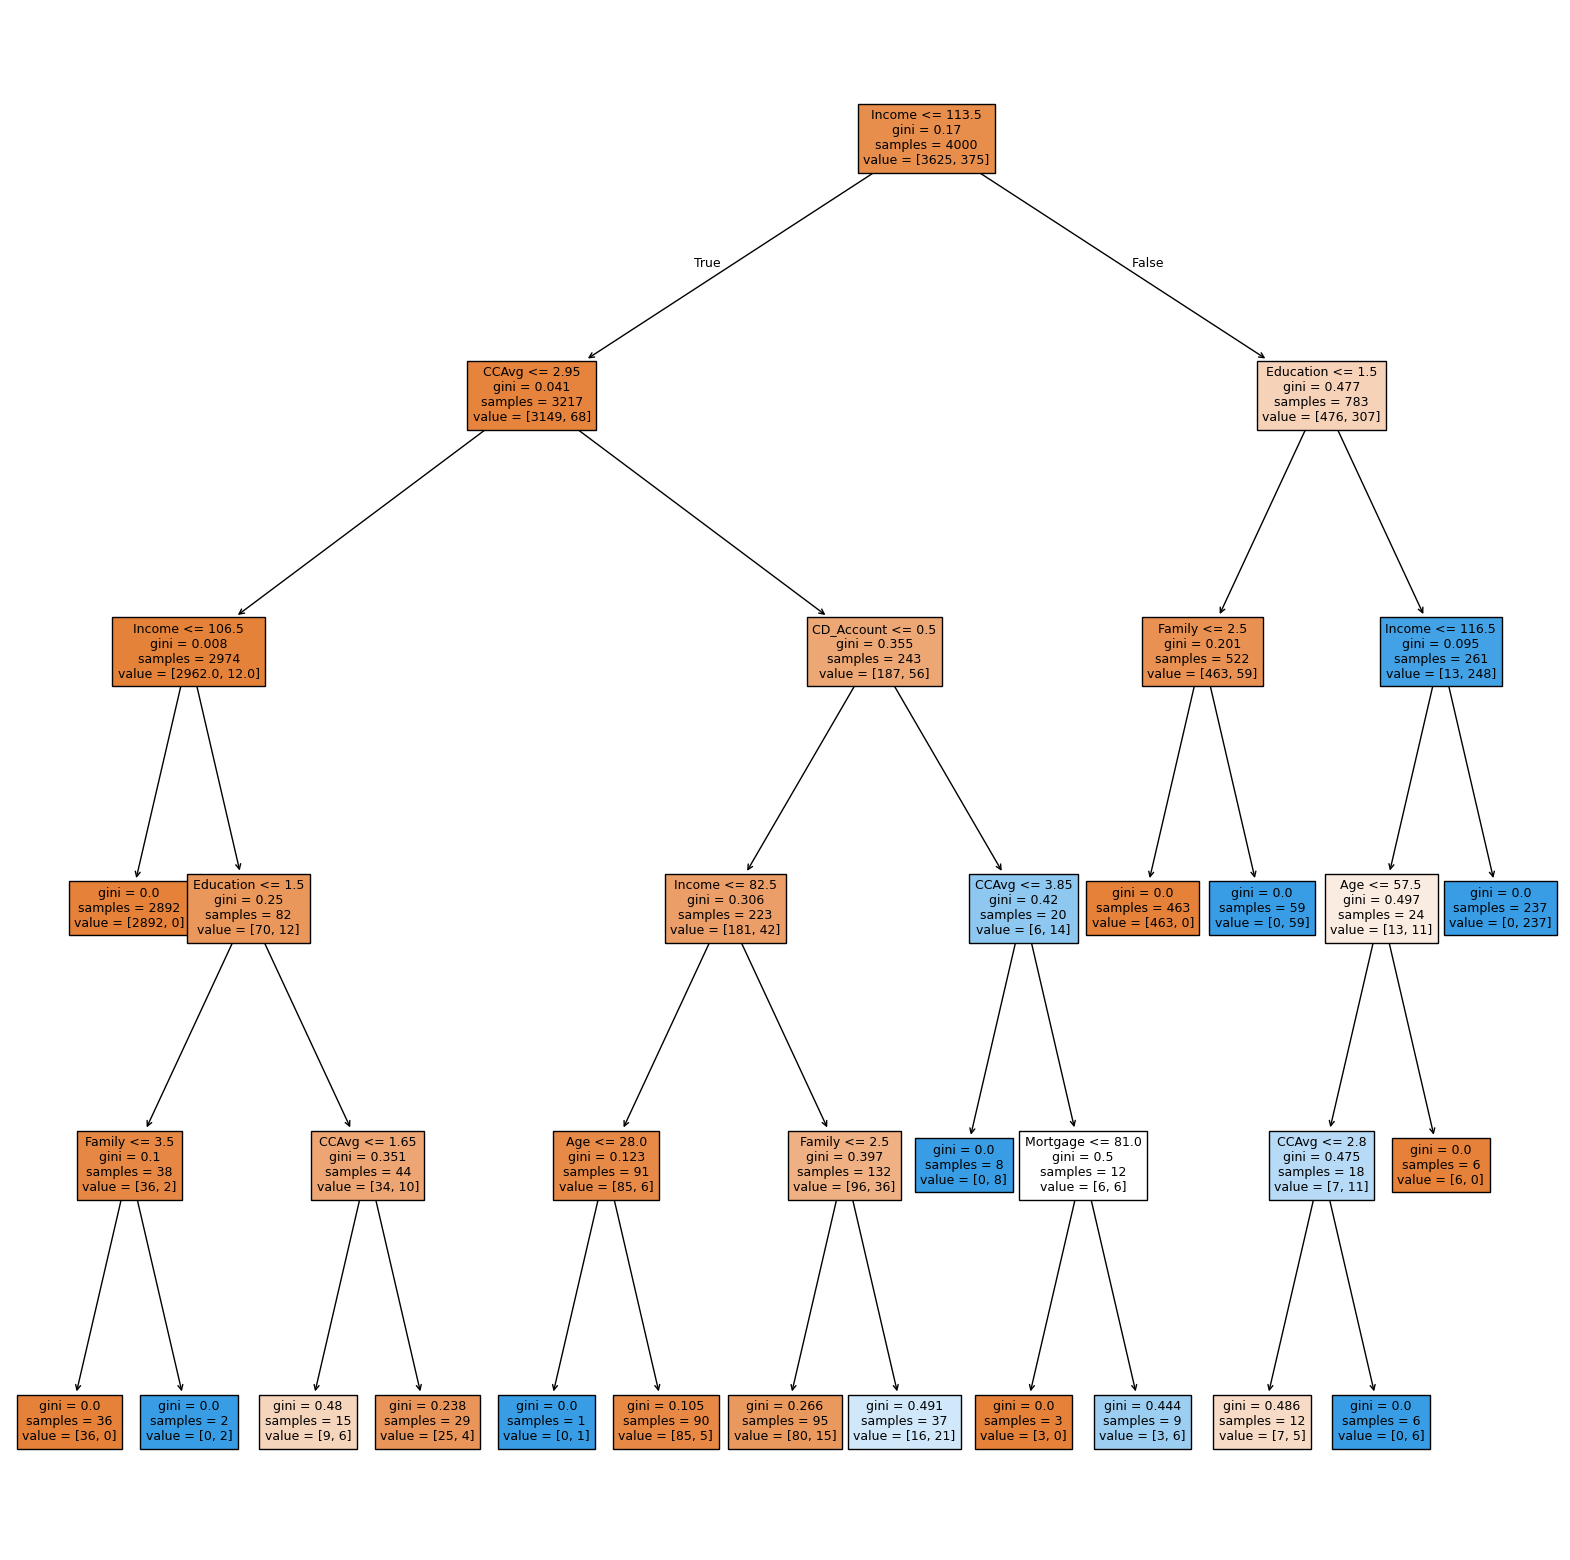

In [757]:
plot_decision_tree(pre_pruned_dt)

In [758]:
export_tree_text(pre_pruned_dt)

|--- Income <= 113.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2892.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Education <= 1.50
|   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |--- weights: [36.00, 0.00] class: 0
|   |   |   |   |--- Family >  3.50
|   |   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Education >  1.50
|   |   |   |   |--- CCAvg <= 1.65
|   |   |   |   |   |--- weights: [9.00, 6.00] class: 0
|   |   |   |   |--- CCAvg >  1.65
|   |   |   |   |   |--- weights: [25.00, 4.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Income <= 82.50
|   |   |   |   |--- Age <= 28.00
|   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |--- Age >  28.00
|   |   |   |   |   |--- weights: [85.00, 5.00] class: 0
|   |   |   |--- Income >  82.50
|   |   |   |   |--- Family <= 2.50
|   |   |   |   |   |--- weights: [80.00, 15.00] class: 0
|   |   | 

This PrePruning Tree is not overfitted and better generalized. Also We can interpret this tree much easily than the Default tree.

### Post-Pruning Decision Tree

* Post-Pruning is an alternate process to prune a tree
* In Post-Pruning nodes and subtrees are replaced with leaves to reduce complexity

## Building Post-Pruning Decision Tree

In [759]:
# Create an instance of the decision tree model
clf = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=6)

# Compute the cost complexity pruning path for the model using the training data
path = clf.cost_complexity_pruning_path(X_train, Y_train)

# Extract the array of effective alphas from the pruning path
ccp_alphas = abs(path.ccp_alphas)

# Extract the array of total impurities at each alpha along the pruning path
impurities = path.impurities

In [760]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.000000e+00,0.019824
1,1.048051e-16,0.019824
2,1.403322e-16,0.019824
3,2.060574e-16,0.019824
4,2.588654e-04,0.020083
5,2.595311e-04,0.020342
6,2.824675e-04,0.020625
7,2.898620e-04,0.021204
8,4.833333e-04,0.021688
9,5.297840e-04,0.023277


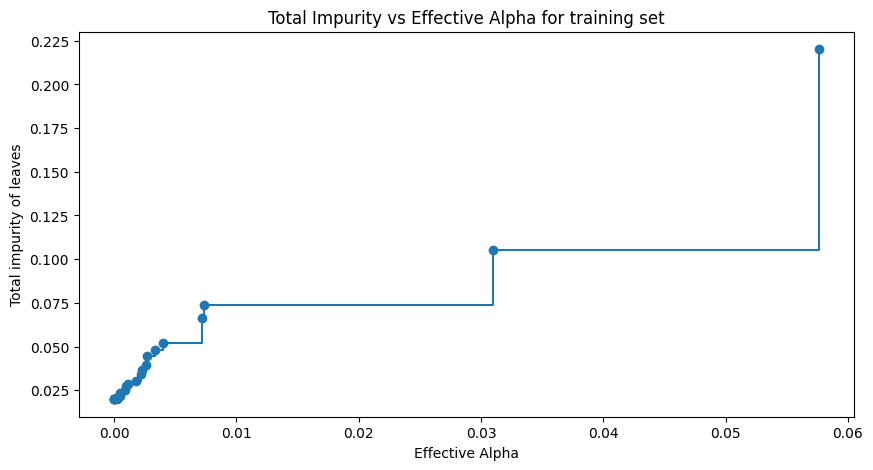

In [761]:
# Create a figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the total impurities versus effective alphas, excluding the last value,
# using markers at each data point and connecting them with steps
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")

# Set the x-axis label
ax.set_xlabel("Effective Alpha")

# Set the y-axis label
ax.set_ylabel("Total impurity of leaves")

# Set the title of the plot
ax.set_title("Total Impurity vs Effective Alpha for training set");

As Alpha increases total impurity increase

In [762]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=ccp_alpha, random_state=42, class_weight='balanced', max_depth=6)
    clf.fit(X_train, Y_train)
    clfs.append(clf)

# Print the number of nodes in the last tree along with its ccp_alpha value
print(
    "Number of nodes in the last tree is {} with ccp_alpha {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is 1 with ccp_alpha 0.27983896368075617


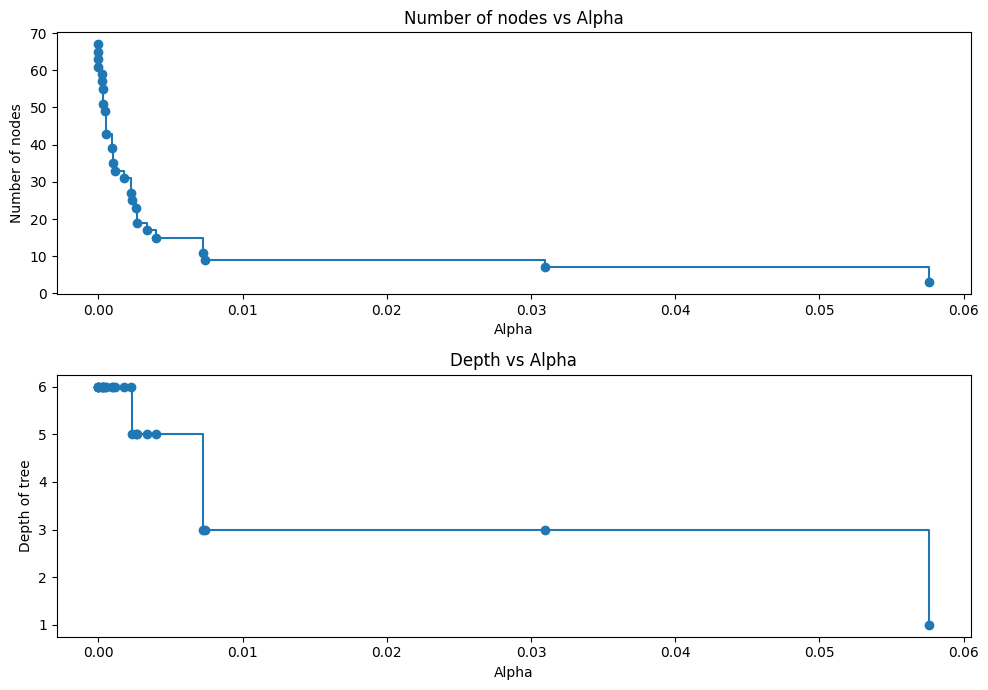

In [763]:
# Remove the last classifier and corresponding ccp_alpha value from the lists
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Extract the number of nodes in each tree classifier
node_counts = [clf.tree_.node_count for clf in clfs]

# Extract the maximum depth of each tree classifier
depth = [clf.tree_.max_depth for clf in clfs]

# Create a figure and a set of subplots
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Plot the number of nodes versus ccp_alphas on the first subplot
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("Alpha")
ax[0].set_ylabel("Number of nodes")
ax[0].set_title("Number of nodes vs Alpha")

# Plot the depth of tree versus ccp_alphas on the second subplot
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Depth of tree")
ax[1].set_title("Depth vs Alpha")

# Adjust the layout of the subplots to avoid overlap
fig.tight_layout()

As Aplha increases the depth of the tree, number of nodes decreases.

In [764]:
train_f1_scores = []  # Initialize an empty list to store F1 scores for training set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the training set using the current decision tree classifier
    pred_train = clf.predict(X_train)

    # Calculate the F1 score for the training set predictions compared to true labels
    f1_train = f1_score(Y_train, pred_train)

    # Append the calculated F1 score to the train_f1_scores list
    train_f1_scores.append(f1_train)

In [765]:
test_f1_scores = []  # Initialize an empty list to store F1 scores for test set for each decision tree classifier

# Iterate through each decision tree classifier in 'clfs'
for clf in clfs:
    # Predict labels for the test set using the current decision tree classifier
    pred_test = clf.predict(X_test)

    # Calculate the F1 score for the test set predictions compared to true labels
    f1_test = f1_score(Y_test, pred_test)

    # Append the calculated F1 score to the test_f1_scores list
    test_f1_scores.append(f1_test)


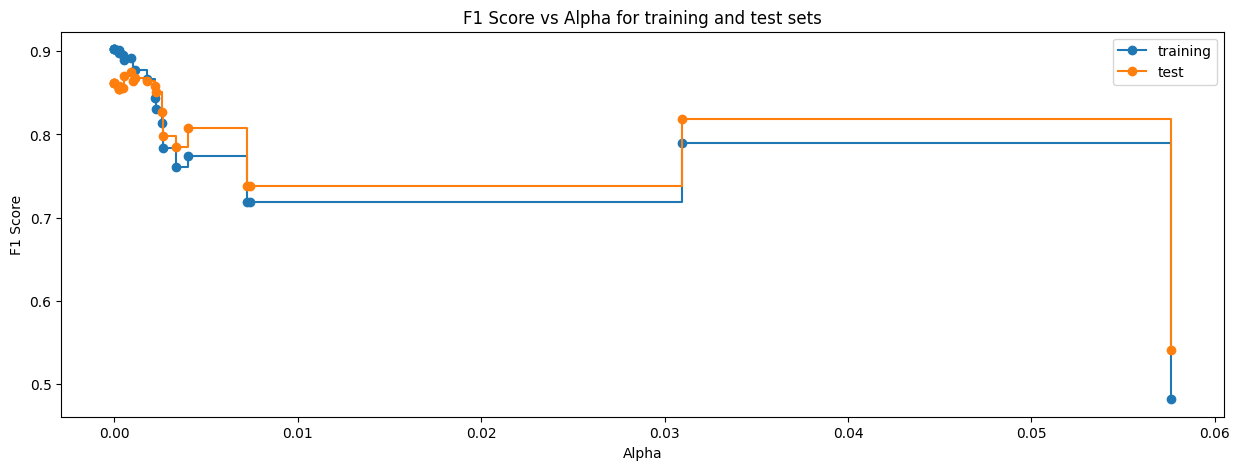

In [766]:
# Create a figure
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("Alpha")  # Set the label for the x-axis
ax.set_ylabel("F1 Score")  # Set the label for the y-axis
ax.set_title("F1 Score vs Alpha for training and test sets")  # Set the title of the plot

# Plot the training F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, train_f1_scores, marker="o", label="training", drawstyle="steps-post")

# Plot the testing F1 scores against alpha, using circles as markers and steps-post style
ax.plot(ccp_alphas, test_f1_scores, marker="o", label="test", drawstyle="steps-post")

ax.legend();  # Add a legend to the plot

In [767]:
# creating the model where we get highest test F1 Score
index_best_model = np.argmax(test_f1_scores)

# selcting the decision tree model corresponding to the highest test score
post_pruning_decision_tree = clfs[index_best_model]
print(post_pruning_decision_tree)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0009203443328550735),
                       class_weight='balanced', max_depth=6, random_state=42)


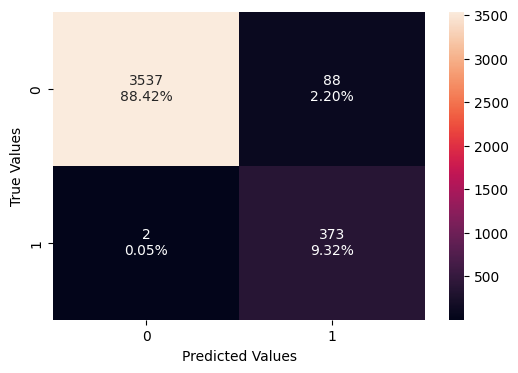

In [768]:
plot_confusion_matrix(post_pruning_decision_tree, X_train, Y_train)

In [769]:
post_pruning_train_perf = model_performance_classification(
    post_pruning_decision_tree, X_train, Y_train
)
post_pruning_train_perf

,Accuracy,Recall,Precision,F1
0,0.9775,0.994667,0.809111,0.892344


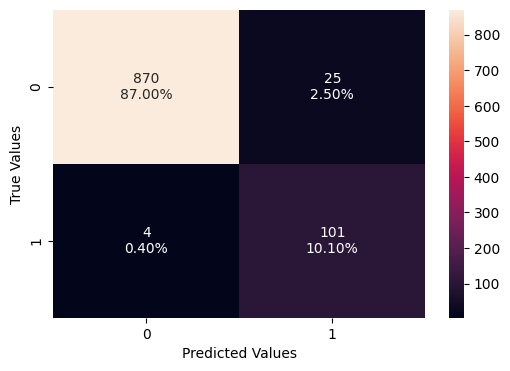

In [770]:
plot_confusion_matrix(post_pruning_decision_tree, X_test, Y_test)

In [771]:
post_pruning_test_perf = model_performance_classification(
    post_pruning_decision_tree, X_test, Y_test
)
post_pruning_test_perf

,Accuracy,Recall,Precision,F1
0,0.971,0.961905,0.801587,0.874459


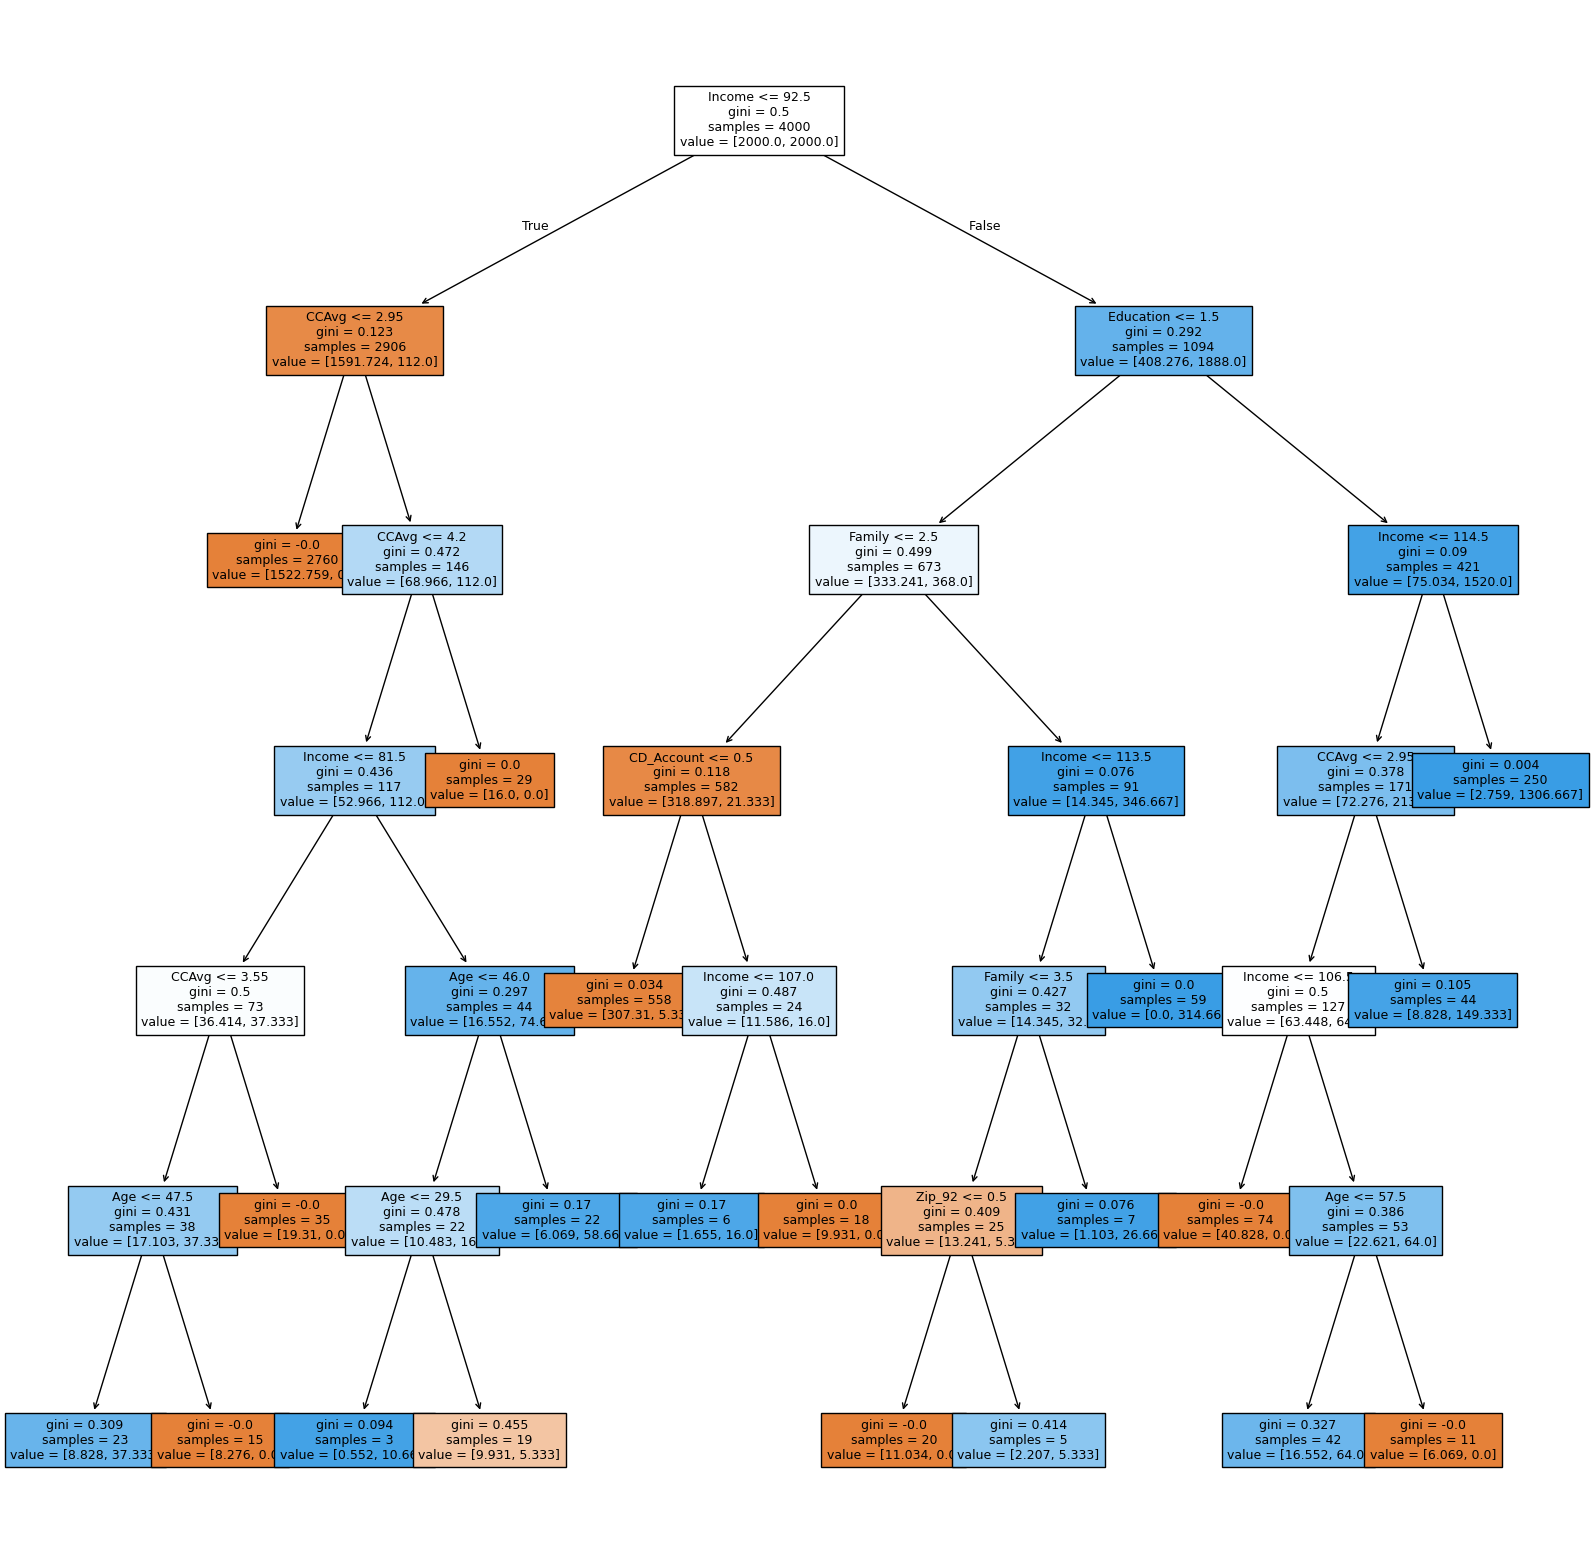

In [772]:
plot_decision_tree(post_pruning_decision_tree)

In [773]:
export_tree_text(post_pruning_decision_tree)

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1522.76, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CCAvg <= 4.20
|   |   |   |--- Income <= 81.50
|   |   |   |   |--- CCAvg <= 3.55
|   |   |   |   |   |--- Age <= 47.50
|   |   |   |   |   |   |--- weights: [8.83, 37.33] class: 1
|   |   |   |   |   |--- Age >  47.50
|   |   |   |   |   |   |--- weights: [8.28, 0.00] class: 0
|   |   |   |   |--- CCAvg >  3.55
|   |   |   |   |   |--- weights: [19.31, 0.00] class: 0
|   |   |   |--- Income >  81.50
|   |   |   |   |--- Age <= 46.00
|   |   |   |   |   |--- Age <= 29.50
|   |   |   |   |   |   |--- weights: [0.55, 10.67] class: 1
|   |   |   |   |   |--- Age >  29.50
|   |   |   |   |   |   |--- weights: [9.93, 5.33] class: 0
|   |   |   |   |--- Age >  46.00
|   |   |   |   |   |--- weights: [6.07, 58.67] class: 1
|   |   |--- CCAvg >  4.20
|   |   |   |--- weights: [16.00, 0.00] class: 0
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- Family <= 

### Model Performance Comparison and Final Model Selection

In [774]:
# training performance comparison
models_train_comp_df = pd.concat(
    [
        dt_train_data_performace.T,
        pre_pruned_dt_train_perf.T,
        post_pruning_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.0,0.986500,0.977500
Recall,1.0,0.906667,0.994667
Precision,1.0,0.947075,0.809111
F1,1.0,0.926431,0.892344


In [775]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        dt_test_data_performance.T,
        pre_pruned_dt_test_perf.T,
        post_pruning_test_perf.T
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.982000,0.984000,0.971000
Recall,0.895238,0.914286,0.961905
Precision,0.930693,0.932039,0.801587
F1,0.912621,0.923077,0.874459


Default SKlearn Decision Tree exhibits Overfitting. To Overcome this, we build Pre-Pruned Decision tree and Post-Pruned decision tree.
Both the pre-pruned and post-pruned decision trees are much less complicated and exhibits generalized performance.

Income, CC Avg, Education, Family, Age are the main factors considered in Pre-Pruned decision Tree. Post Pruned Decision Tree considers CD Account and zipcode in addition to Income, CC Avg, Education, Family, Age are the main factors considered in Pre-Pruned decision Tree.

The pre-pruned decision tree has higher accuracy, precision, F1 score and almost the same recall on train and test sets promising optimized and higher results than the post-pruned and the default models.

Another advantage is the Pre-pruned model can be highly customized using max_depth, minimum leaves per node, minimum splits per node

In Addition to that pre-pruned model is comparitively quicker and computationally less expensive than the Post-pruned decision tree.

So we will select Post Pruned Tree as our final model.

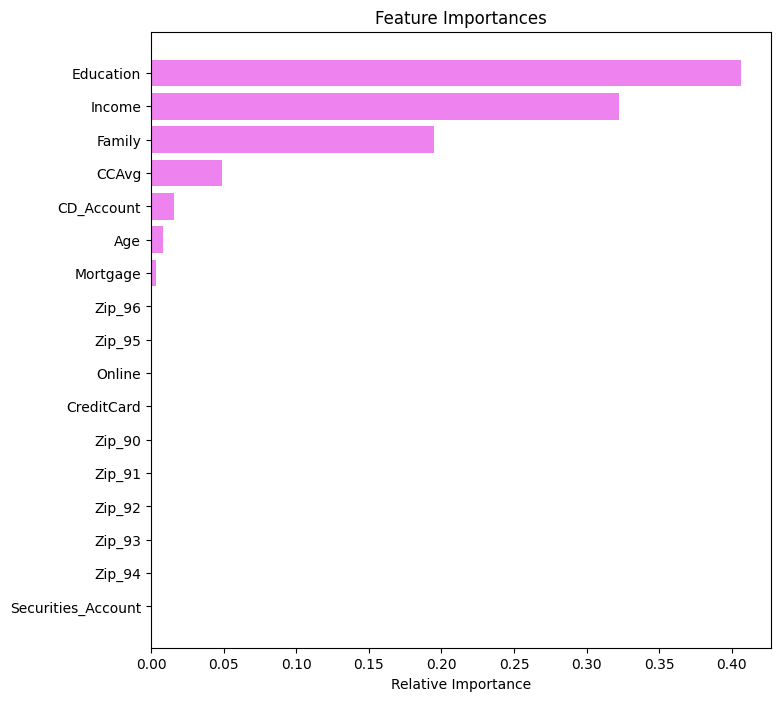

In [776]:
# importance of features in the tree building
feature_names = list(X_train.columns)
importances = pre_pruned_dt.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Actionable Insights and Business Recommendations


___

### Key Insights

* The top key features effecting the loan acceptance rate are Education, income, Family, age and CC Avg
* Higher annual income customers(>$80-85 K have higher acceptance rates)
* Graduate or advanced education is associated with higher loan uptake
* Middle aged customers are more responsive than the youngest or oldest groups.
* Smaller families show higher acceptance
* Customers with CD Account are far more likely to accept a loan
* Monthly Credit card spend >3k strongly signals aceptance.

* Younger customers or much older (>57) with long spend and larger families are unlikely to accept the personal loan
* Customers with no CD Account and less income have low probability of accepting the loan


### Business Recommendations

**Targeted Marketing**
* Cross-sell to CD Account holders by promoting bundled offers. For example, by offering special rate personal loan for CD Customers
* Increase advertising and campaigns for high income/ high spend customers with personalized loan rates

**Pricing Offers**
* Offer fee waivers to those maintaining and paying Credit card users in time
* Provide less interest rates for middle income families to improve afforadability

**Educated-Based Recommendations**
* Run campaigns For Graduates/advanced educated customers highlighting financial planning benifits.
* Advertise Digital Banking, email and other flexibilties to customers who use online banking.

### Monitoring Next Steps

* Continously feed new loan acceptance data back into the model to refine thresholds regularly.
* Track ROI on campaigns focusing on CD holders vs non-CD holders

